In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

In [22]:
participant = "40_HeSe"

def get_imot(id):
    path = './data/' + participant + '/i_' + 'Shovel' + '_' + id + '.csv'
    return pd.read_csv(path)

def get_unity(id):
    path = './data/' + participant + '/u_' + 'Shovel' + '_' + id + '.csv'
    return pd.read_csv(path)

c_0_i_raw = get_imot("C0")
c_1_i_raw = get_imot("C1")
c_2_i_raw = get_imot("C2")
p_0_i_raw = get_imot("P0")
p_1_i_raw = get_imot("P1")
p_2_i_raw = get_imot("P2")

c_0_i_raw.head(3)

,Row,Timestamp,EventSource,SlideEvent,StimType,Duration,CollectionPhase,SourceStimuliName,EventSource.1,Heart rate,...,VSenseBatt RAW,VSenseBatt CAL,Internal ADC A13 PPG RAW,Internal ADC A13 PPG CAL,GSR RAW,GSR Resistance CAL,GSR Conductance CAL,Heart Rate PPG ALG,IBI PPG ALG,Packet reception rate RAW
0,1,4,SlideEvents,StartSlide,TestImage,3000000.0,StimuliDisplay,Screen recording 1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2679.0,3901.723077,2603.0,1906.959707,19882.0,69.571124,14.373780,-1.0,-1.0,99.0
2,3,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2679.0,3901.723077,2604.0,1907.692308,19878.0,69.670105,14.353359,-1.0,-1.0,99.0


In [23]:
c_0_u = get_unity("C0")
c_1_u = get_unity("C1")
c_2_u = get_unity("C2")
p_0_u = get_unity("P0")
p_1_u = get_unity("P1")
p_2_u = get_unity("P2")

c_0_u.head(3)

,ts_datetime,ts_unix_ms,primary_grab_hand,pt_x,pt_y,pt_z,st_x,st_y,st_z,pv_x,...,hmd_x,hmd_y,hmd_z,ee_x,ee_y,ee_z,shovel_loaded_state,cube_max_target_reached,grab_count,collision_or_load_count
0,7/15/2025 5:15:39 PM,1752592539713,Right,0.000472,0.070352,0.027367,-0.008219,0.058164,0.508151,0.000472,...,0.162736,0.605256,0.293182,-0.000214,0.070009,0.739998,False,0.0,1.0,0.0
1,7/15/2025 5:15:39 PM,1752592539728,Right,0.001087,0.070320,0.027886,-0.008026,0.059247,0.508052,0.001087,...,0.162364,0.604886,0.294442,-0.039498,0.095630,0.768029,False,0.0,1.0,0.0
2,7/15/2025 5:15:39 PM,1752592539754,Right,0.004302,0.070373,0.028029,-0.008262,0.058232,0.508550,0.004302,...,0.161735,0.604285,0.296712,-0.042235,0.093641,0.767889,False,0.0,1.0,0.0


In [24]:
unity_unix_key = "ts_unix_ms"
imot_unix_key = "System Timestamp CAL"
imot_ms_key = "Timestamp"
baseline_ms = 30_000

def task_start(df):
    return df[unity_unix_key].min()

def task_end(df):
    final_load = df[(df["collision_or_load_count"] == 20)]
    final_unload = final_load[(final_load["shovel_loaded_state"] == False)]

    return final_unload[unity_unix_key].min()

def get_trimmed_imot(df, unity_df):
    start = task_start(unity_df) - baseline_ms
    end = task_end(unity_df) + baseline_ms
    
    imot_start = df.dropna(subset = imot_unix_key).iloc[0][imot_unix_key]

    start_trimmed = df[(imot_start + df["Timestamp"] >= start)]

    return start_trimmed[(imot_start + start_trimmed["Timestamp"] <= end)]

In [25]:
c_0_i = get_trimmed_imot(c_0_i_raw, c_0_u)
c_1_i = get_trimmed_imot(c_1_i_raw, c_1_u)
c_2_i = get_trimmed_imot(c_2_i_raw, c_2_u)
p_0_i = get_trimmed_imot(p_0_i_raw, p_0_u)
p_1_i = get_trimmed_imot(p_1_i_raw, p_1_u)
p_2_i = get_trimmed_imot(p_2_i_raw, p_2_u)

print("Unity grab start minus Baseline: ", c_0_u.iloc[0][unity_unix_key] - baseline_ms)
print("First trimmed iMotions entry:    ", c_0_i.dropna(subset = imot_unix_key).iloc[0][imot_unix_key])

Unity grab start minus Baseline:  1752592509713
First trimmed iMotions entry:     1752592509702.2598


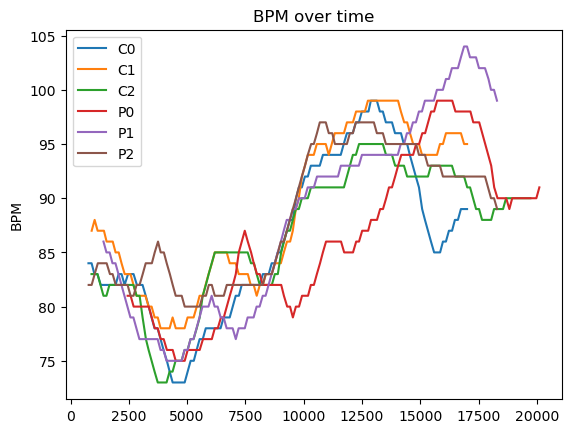

In [26]:
hr_key = 'Heart rate'

def plot_hr(df, label):
    df_cleaned = df.dropna(subset = hr_key)
    plt.plot(df_cleaned[hr_key], label=label)

plot_hr(c_0_i, "C0")
plot_hr(c_1_i, "C1")
plot_hr(c_2_i, "C2")
plot_hr(p_0_i, "P0")
plot_hr(p_1_i, "P1")
plot_hr(p_2_i, "P2")


plt.legend()
plt.title('BPM over time')
plt.ylabel('BPM')
#display plot
plt.show()

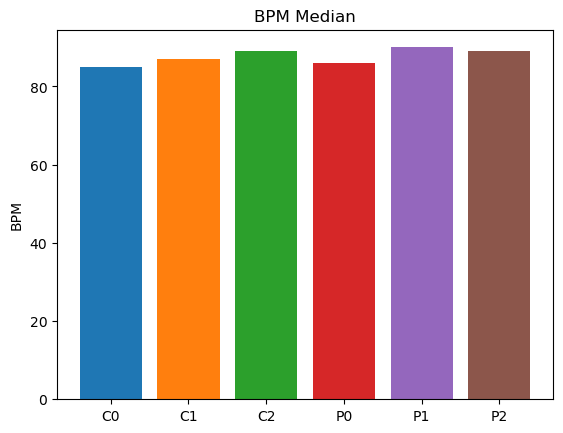

In [27]:
def median_hr(df):
    df_cleaned = df.dropna(subset = hr_key)
    return df_cleaned[hr_key].median()

labels = ['C0', 'C1', 'C2', 'P0', 'P1', 'P2']
deltas = [
    median_hr(c_0_i),
    median_hr(c_1_i),
    median_hr(c_2_i),
    median_hr(p_0_i),
    median_hr(p_1_i),
    median_hr(p_2_i)
    ]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

plt.bar(labels, deltas, color=colors)
plt.title('BPM Median')
plt.ylabel('BPM')
plt.show()

C:\Users\elias\AppData\Local\Temp\ipykernel_27716\2006796447.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_smoothed['SMA'] = df_smoothed[gsr_key].rolling(window=128).mean()
C:\Users\elias\AppData\Local\Temp\ipykernel_27716\2006796447.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_smoothed['SMA'] = df_smoothed[gsr_key].rolling(window=128).mean()
C:\Users\elias\AppData\Local\Temp\ipykernel_27716\2006796447.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

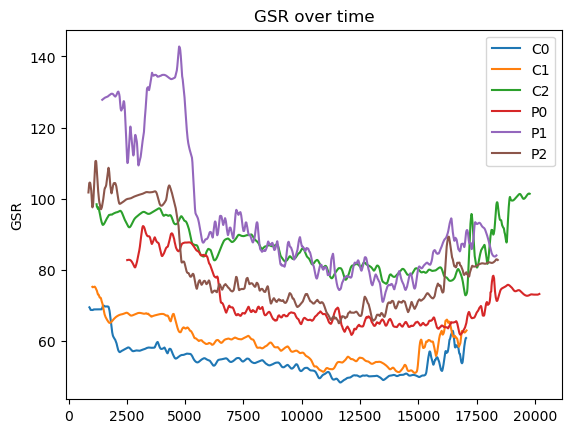

In [28]:
gsr_key = 'GSR Resistance CAL'
gsc_key = 'GSR Conductance CAL'
max_z_score = 3

def plot_gsr(df, label):
    df_cleaned = df.dropna(subset = gsr_key)
    df_smoothed = df_cleaned[np.abs(stats.zscore(df_cleaned[gsr_key])) < max_z_score]

    #df_smoothed['SMA'] = df_smoothed[gsr_key]
    df_smoothed['SMA'] = df_smoothed[gsr_key].rolling(window=128).mean()
    plt.plot(df_smoothed['SMA'], label=label)

plot_gsr(c_0_i, "C0")
plot_gsr(c_1_i, "C1")
plot_gsr(c_2_i, "C2")
plot_gsr(p_0_i, "P0")
plot_gsr(p_1_i, "P1")
plot_gsr(p_2_i, "P2")


plt.legend()
plt.title('GSR over time')
plt.ylabel('GSR')
#display plot
plt.show()

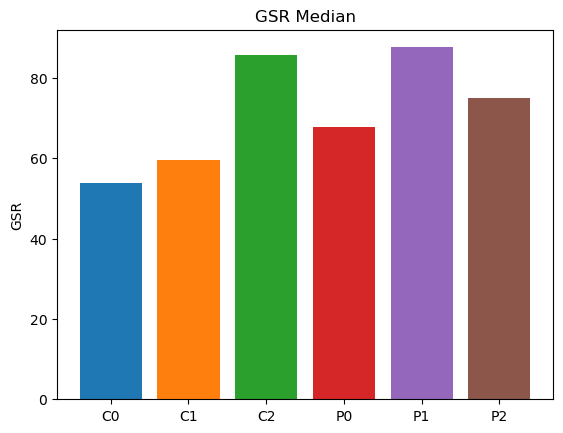

In [29]:
def median_gsr(df):
    df_cleaned = df.dropna(subset = gsr_key)
    df_smoothed = df_cleaned[np.abs(stats.zscore(df_cleaned[gsr_key])) < max_z_score]
    return df_smoothed[gsr_key].median()

labels = ['C0', 'C1', 'C2', 'P0', 'P1', 'P2']
deltas = [
    median_gsr(c_0_i),
    median_gsr(c_1_i),
    median_gsr(c_2_i),
    median_gsr(p_0_i),
    median_gsr(p_1_i),
    median_gsr(p_2_i)
    ]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

plt.bar(labels, deltas, color=colors)
plt.title('GSR Median')
plt.ylabel('GSR')
plt.show()

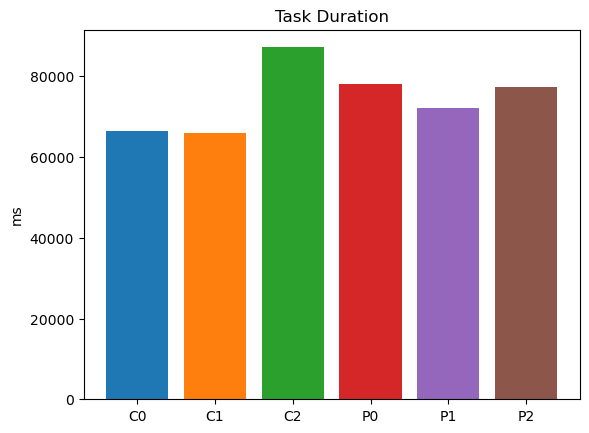

In [30]:
def task_duration(df):
    return task_end(df) - task_start(df)

labels = ['C0', 'C1', 'C2', 'P0', 'P1', 'P2']
deltas = [
    task_duration(c_0_u),
    task_duration(c_1_u),
    task_duration(c_2_u),
    task_duration(p_0_u),
    task_duration(p_1_u),
    task_duration(p_2_u)
    ]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

plt.bar(labels, deltas, color=colors)
plt.title('Task Duration')
plt.ylabel('ms')
plt.show()